## DATA visualization


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


best_sellers_data = pd.read_csv("bestsellers with categories.csv")
best_sellers_data
#### basic data analysis
best_sellers_data.info()
best_sellers_data['Name'].nunique()
best_sellers_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    object 
 1   Author       550 non-null    object 
 2   User Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Price        550 non-null    int64  
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 30.2+ KB


,User Rating,Reviews,Price,Year
count,550.000000,550.000000,550.000000,550.000000
mean,4.618364,11953.281818,13.100000,2014.000000
std,0.226980,11731.132017,10.842262,3.165156
min,3.300000,37.000000,0.000000,2009.000000
25%,4.500000,4058.000000,7.000000,2011.000000
50%,4.700000,8580.000000,11.000000,2014.000000
75%,4.800000,17253.250000,16.000000,2017.000000
max,4.900000,87841.000000,105.000000,2019.000000


##  Q1 

#### top 10 authors with high average reviews & top rating authors every year by high user reviews

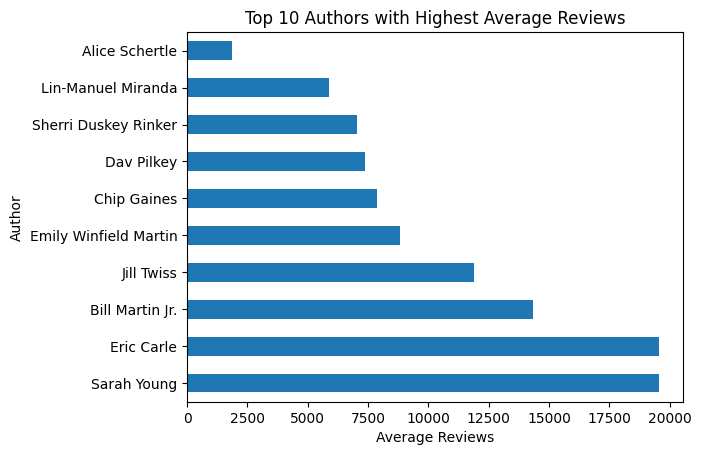

In [9]:
best_sellers_data[best_sellers_data['Price'] == 0]
best_sellers_data
best_sellers_data[best_sellers_data['User Rating'] == 4.8]
high_rating_authors = best_sellers_data[best_sellers_data['Author'].isin(best_sellers_data.groupby('Author')['User Rating'].agg('mean').sort_values(ascending=False).head(10).index)]
best_sellers_data[best_sellers_data['Year'] == 2010].sort_values(by= 'User Rating', ascending=False).head(10)
high_rating_authors['Year'].unique()
high_rating_authors.dtypes
high_rating_authors.groupby('Author')['Reviews'].agg('mean').sort_values(ascending=False).plot(kind= 'barh')
plt.xlabel('Average Reviews')
plt.title('Top 10 Authors with Highest Average Reviews')
plt.show()
high_reviews_by_year = high_rating_authors.groupby(['Year', 'Author'])['Reviews'].mean()
high_reviews_by_year.groupby('Year').head(1)
high_reviews_by_year = high_rating_authors.groupby(['Year', 'Author'])['Reviews'].mean().reset_index()
high_reviews_by_year = high_reviews_by_year.sort_values(['Year', 'Reviews'], ascending=[True, False])

In [49]:
high_rating_authors = best_sellers_data[best_sellers_data['Author'].isin(best_sellers_data.groupby('Author')['User Rating'].agg('mean').sort_values(ascending=False).head(10).index)]
high_rating_authors

,Name,Author,User Rating,Reviews,Price,Year,Genre
40,"Brown Bear, Brown Bear, What Do You See?",Bill Martin Jr.,4.9,14344,5,2017,Fiction
41,"Brown Bear, Brown Bear, What Do You See?",Bill Martin Jr.,4.9,14344,5,2019,Fiction
81,Dog Man and Cat Kid: From the Creator of Capta...,Dav Pilkey,4.9,5062,6,2018,Fiction
82,Dog Man: A Tale of Two Kitties: From the Creat...,Dav Pilkey,4.9,4786,8,2017,Fiction
83,Dog Man: Brawl of the Wild: From the Creator o...,Dav Pilkey,4.9,7235,4,2018,Fiction
84,Dog Man: Brawl of the Wild: From the Creator o...,Dav Pilkey,4.9,7235,4,2019,Fiction
85,Dog Man: Fetch-22: From the Creator of Captain...,Dav Pilkey,4.9,12619,8,2019,Fiction
86,Dog Man: For Whom the Ball Rolls: From the Cre...,Dav Pilkey,4.9,9089,8,2019,Fiction
87,Dog Man: Lord of the Fleas: From the Creator o...,Dav Pilkey,4.9,5470,6,2018,Fiction
146,"Goodnight, Goodnight Construction Site (Hardco...",Sherri Duskey Rinker,4.9,7038,7,2012,Fiction


Text(0.5, 1.0, 'Top Author per Year by Average Reviews')

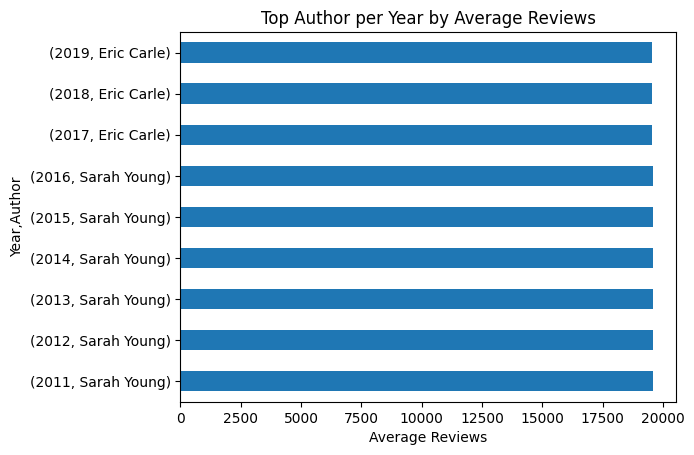

In [10]:
top1_author_per_year = high_reviews_by_year.groupby('Year').head(1)
top1_author_per_year
top1_author_per_year.groupby(['Year', 'Author'])['Reviews'].mean().plot(kind='barh')
plt.xlabel('Average Reviews')
plt.title('Top Author per Year by Average Reviews')

## Q2

#### High revenued author all over the years

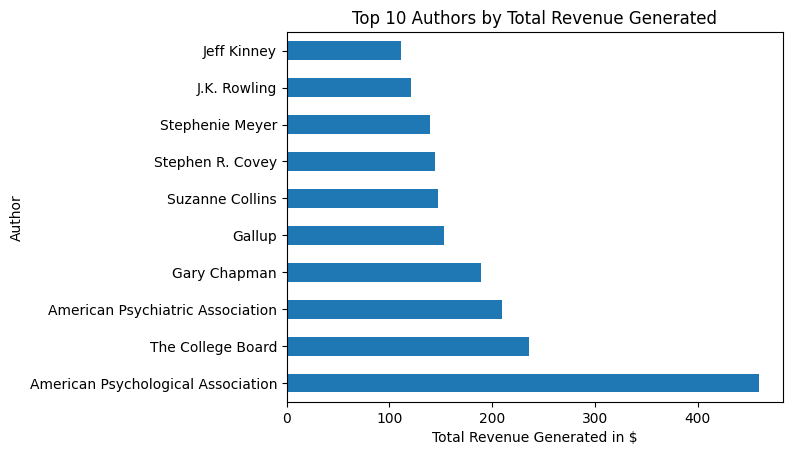

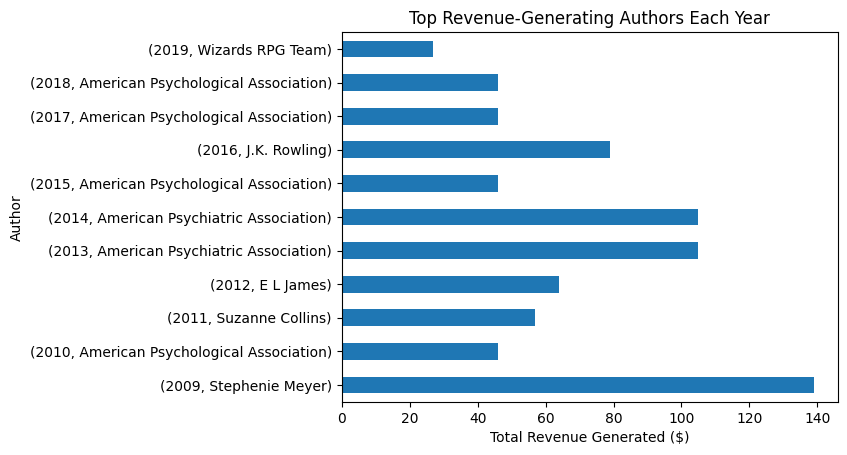

<function matplotlib.pyplot.xscale(value: 'str | ScaleBase', **kwargs) -> 'None'>

In [11]:
best_sellers_data
revenue_by_authors = best_sellers_data.groupby('Author')['Price'].agg('sum')
revenue_by_authors.sort_values(ascending=False).head(10).plot(kind='barh')
plt.xlabel('Total Revenue Generated in $')
plt.title('Top 10 Authors by Total Revenue Generated')
plt.show()
best_sellers_data.groupby(['Year', 'Author'])['Price'].sum().sort_values(ascending=False)
high_revenue_authors_byyear = best_sellers_data.groupby(['Year', 'Author'])['Price'].sum().reset_index()
high_revenue_authors_byyear = high_revenue_authors_byyear.sort_values(['Year', 'Price'], ascending=[True, False])

high_revenue_authors_every_year = high_revenue_authors_byyear.groupby('Year').head(1)
high_revenue_authors_every_year
high_revenue_authors_every_year.groupby(['Year', 'Author'])['Price'].mean().plot(kind='barh')
plt.xlabel('Total Revenue Generated ($)')
plt.ylabel('Author')
plt.title('Top Revenue-Generating Authors Each Year')
plt.show()
plt.xscale

## Q3

#### top 10 high revenue genereted publications & top revenue genereted publication each year

C:\Users\sanja\AppData\Local\Temp\ipykernel_6568\185756266.py:3: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  best_sellers_data.groupby(['Year', 'Name'])['Price'].agg(sum).sort_values(ascending=False)


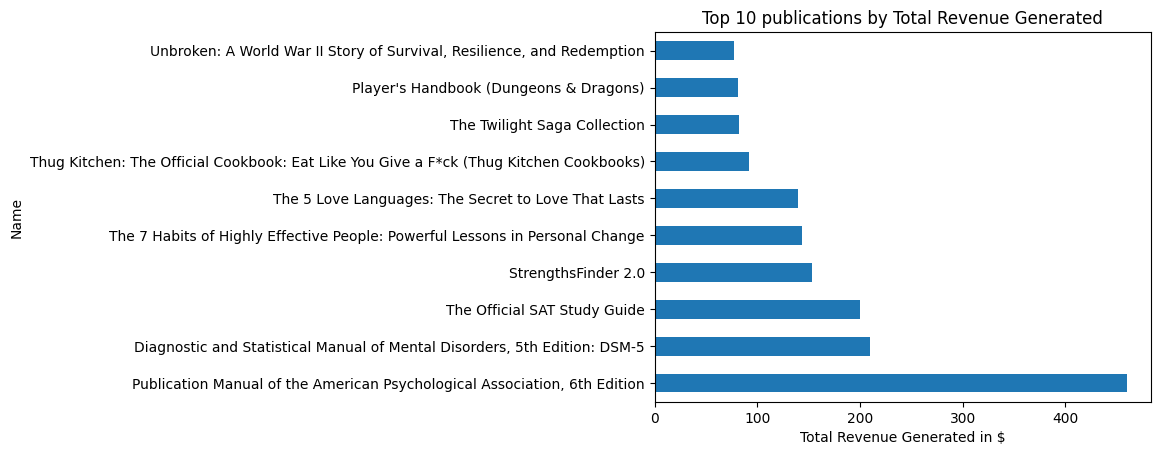

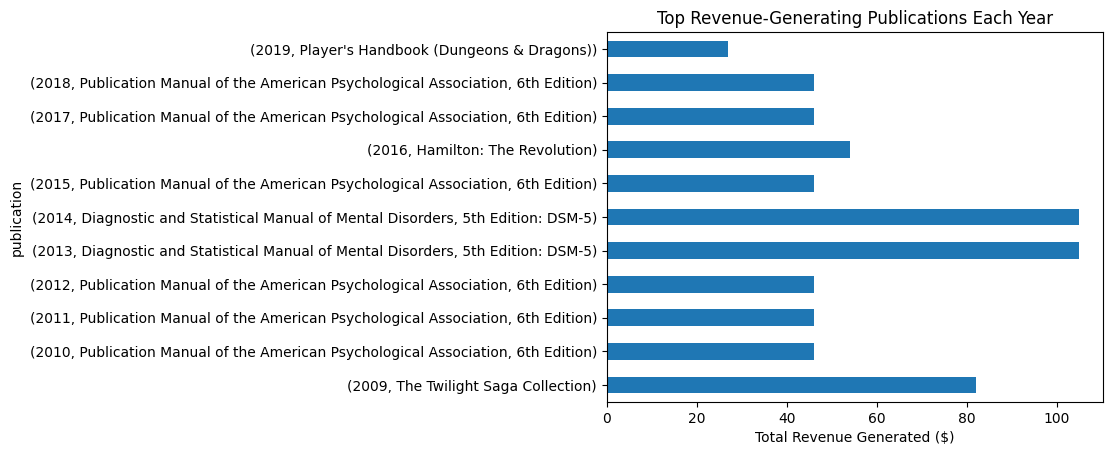

In [29]:
best_sellers_data
best_sellers_data['Name'].nunique()
best_sellers_data.groupby(['Year', 'Name'])['Price'].agg(sum).sort_values(ascending=False)
revenue_gen_bypubs = best_sellers_data.groupby('Name')['Price'].agg('sum')
revenue_gen_bypubs.sort_values(ascending=False).head(10).plot(kind='barh')
plt.xlabel('Total Revenue Generated in $')
plt.title('Top 10 publications by Total Revenue Generated')
plt.show()
high_revenue_pubs_byyear = best_sellers_data.groupby(['Year', 'Name'])['Price'].sum().reset_index()
high_revenue_pubs_byyear = high_revenue_pubs_byyear.sort_values(['Year', 'Price'], ascending=[True, False])

high_revenue_pubs_every_year = high_revenue_pubs_byyear.groupby('Year').head(1)
high_revenue_pubs_every_year
high_revenue_pubs_every_year.groupby(['Year', 'Name'])['Price'].mean().plot(kind='barh')
plt.xlabel('Total Revenue Generated ($)')
plt.ylabel('publication')
plt.title('Top Revenue-Generating Publications Each Year')
plt.show()

## Q4

#### top rating pubs in free price

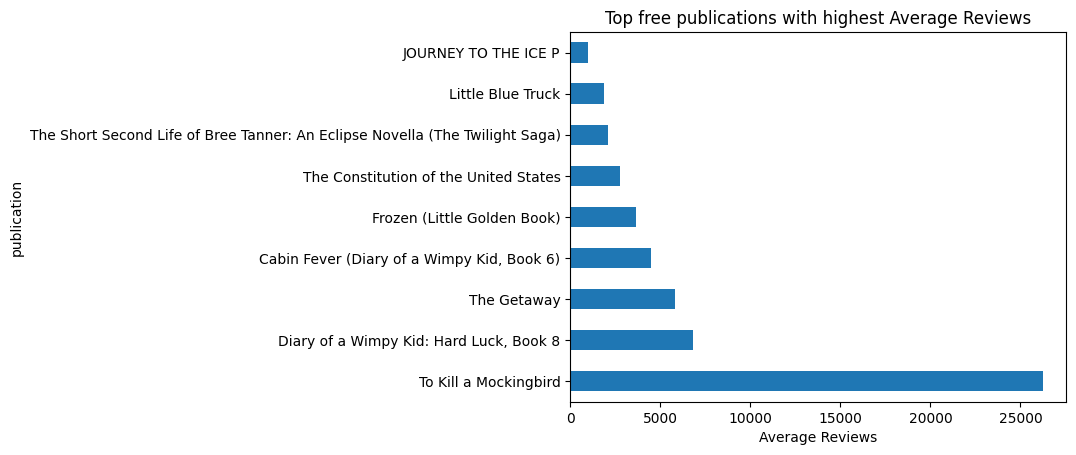

(User Rating  Name                                                                        
 4.6          JOURNEY TO THE ICE P                                                              978.0
              The Short Second Life of Bree Tanner: An Eclipse Novella (The Twilight Saga)     2122.0
 4.7          Frozen (Little Golden Book)                                                      3642.0
 4.8          Cabin Fever (Diary of a Wimpy Kid, Book 6)                                       4505.0
              Diary of a Wimpy Kid: Hard Luck, Book 8                                          6812.0
              The Constitution of the United States                                            2774.0
              The Getaway                                                                      5836.0
              To Kill a Mockingbird                                                           26234.0
 4.9          Little Blue Truck                                                              

In [13]:
free_pubs = best_sellers_data[best_sellers_data['Price'] == 0]
free_pubs

free_pubs.groupby(['User Rating', 'Name'])['Reviews'].mean()
free_pubs.groupby('Name')['Reviews'].agg('mean').sort_values(ascending=False).plot(kind= 'barh')
plt.xlabel('Average Reviews')
plt.ylabel('publication')
plt.title('Top free publications with highest Average Reviews')
plt.show()

sns.boxplot
(
free_pubs.groupby(['User Rating', 'Name'])['Reviews'].mean(),
free_pubs.groupby('Name')['Reviews'].agg('mean').sort_values(ascending=False))

#### comparing fiction and non fiction genre in terms of revenue 

In [30]:
best_sellers_data

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


In [28]:
best_sellers_data[best_sellers_data["Genre"]=='Fiction']

,Name,Author,User Rating,Reviews,Price,Year,Genre
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
5,A Dance with Dragons (A Song of Ice and Fire),George R. R. Martin,4.4,12643,11,2011,Fiction
6,A Game of Thrones / A Clash of Kings / A Storm...,George R. R. Martin,4.7,19735,30,2014,Fiction
7,A Gentleman in Moscow: A Novel,Amor Towles,4.7,19699,15,2017,Fiction
...,...,...,...,...,...,...,...
541,Wonder,R. J. Palacio,4.8,21625,9,2014,Fiction
542,Wonder,R. J. Palacio,4.8,21625,9,2015,Fiction
543,Wonder,R. J. Palacio,4.8,21625,9,2016,Fiction
544,Wonder,R. J. Palacio,4.8,21625,9,2017,Fiction


In [54]:
best_sellers_data.groupby(['Year', 'Name',"Genre"])['Price'].agg(sum).sort_values(ascending=False)

C:\Users\sanja\AppData\Local\Temp\ipykernel_6568\2951488890.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  best_sellers_data.groupby(['Year', 'Name',"Genre"])['Price'].agg(sum).sort_values(ascending=False)


Year  Name                                                                       Genre      
2013  Diagnostic and Statistical Manual of Mental Disorders, 5th Edition: DSM-5  Non Fiction    105
2014  Diagnostic and Statistical Manual of Mental Disorders, 5th Edition: DSM-5  Non Fiction    105
2009  The Twilight Saga Collection                                               Fiction         82
2016  Hamilton: The Revolution                                                   Non Fiction     54
2009  The Book of Basketball: The NBA According to The Sports Guy                Non Fiction     53
                                                                                               ... 
2014  JOURNEY TO THE ICE P                                                       Fiction          0
2013  Diary of a Wimpy Kid: Hard Luck, Book 8                                    Fiction          0
2014  Little Blue Truck                                                          Fiction          0
2013  T

In [35]:
revenue_gen_bypubs = best_sellers_data.groupby('Name')['Price'].agg('sum')
revenue_gen_bypubs

Name
10-Day Green Smoothie Cleanse                                                              8
11/22/63: A Novel                                                                         22
12 Rules for Life: An Antidote to Chaos                                                   15
1984 (Signet Classics)                                                                     6
5,000 Awesome Facts (About Everything!) (National Geographic Kids)                        12
                                                                                          ..
Winter of the World: Book Two of the Century Trilogy                                      15
Women Food and God: An Unexpected Path to Almost Everything                               11
Wonder                                                                                    45
Wrecking Ball (Diary of a Wimpy Kid Book 14)                                               8
You Are a Badass: How to Stop Doubting Your Greatness and Start L

In [64]:
genre_revenues = best_sellers_data.groupby('Genre')["Price"].sum()
genre_revenues

Genre
Fiction        2604
Non Fiction    4601
Name: Price, dtype: int64

<Axes: xlabel='Genre', ylabel='Price'>

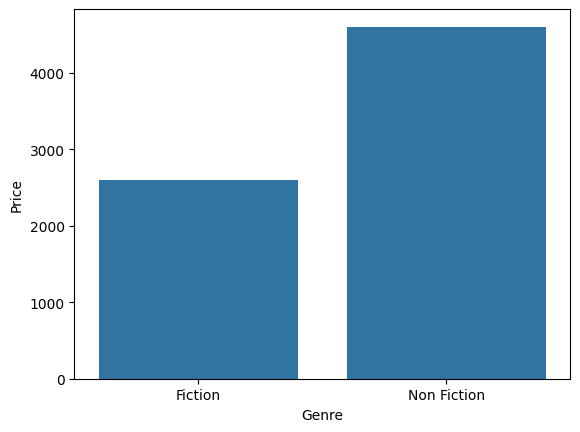

In [72]:
sns.barplot(genre_revenues)